In [ ]:
# IMPORT LIBRARIES

In [1]:
!pip install lightgbm
!pip install optuna
!pip install shap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
import optuna
import shap
import pickle

In [ ]:
#  LOAD DATA

In [3]:
import pandas as pd

df = pd.read_csv("TelcoCustomerChurn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
3. CLEANING

In [4]:
# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing
df.dropna(inplace=True)

# Encode Churn
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})


In [ ]:
# FEATURE ENGINEERING 

In [5]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "")

# Feature Engineering
df['tenure_group'] = df['tenure'].apply(
    lambda x: "Low" if x <= 12 else "Medium" if x <= 48 else "High")

df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

services = [
    'PhoneService','MultipleLines','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]

for col in services:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if x == "Yes" else 0)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure  PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1             0   
1  5575-GNVDE    Male              0      No         No      34             1   
2  3668-QPYBK    Male              0      No         No       2             1   
3  7795-CFOCW    Male              0      No         No      45             0   
4  9237-HQITU  Female              0      No         No       2             1   

   MultipleLines InternetService  OnlineSecurity  ...  StreamingTV  \
0              0             DSL               0  ...            0   
1              0             DSL               1  ...            0   
2              0             DSL               1  ...            0   
3              0             DSL               1  ...            0   
4              0     Fiber optic               0  ...            0   

   StreamingMovies        Contract  PaperlessBilling  \
0                0  Month-to-month  

In [ ]:
# Service Count

In [6]:
# Clean column names
df.columns = df.columns.str.replace(" ", "").str.strip()

# Filter valid service columns
valid_services = [col for col in services if col in df.columns]

# Feature Engineering
df['service_count'] = df[valid_services].sum(axis=1)
df['engagement_score'] = df['tenure'] * df['service_count']

print(df[['service_count','engagement_score']].head())

   service_count  engagement_score
0              1                 1
1              3               102
2              3                 6
3              3               135
4              1                 2


In [ ]:
# ENCODING

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# SPLIT DATA

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 7059)
Test size: (1407, 7059)


In [ ]:
# HANDLE IMBALANCE

In [19]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [ ]:
#  SCALING

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# MULTI-MODEL TRAINING 

In [11]:
models = {
    "RF": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=500),
    "XGB": XGBClassifier(eval_metric='logloss'),
    "LGBM": LGBMClassifier()
}

print("\nMODEL COMPARISON\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


MODEL COMPARISON


RF
Accuracy: 0.7839374555792467
ROC-AUC: 0.8271026706907352

SVM
Accuracy: 0.2658137882018479
ROC-AUC: 0.5

KNN
Accuracy: 0.2658137882018479
ROC-AUC: 0.5

MLP
Accuracy: 0.2658137882018479
ROC-AUC: 0.8069508363056567

XGB
Accuracy: 0.7604832977967306
ROC-AUC: 0.8064409253977046
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1164
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM
Accuracy: 0.7690120824449183
ROC-AUC: 0.8190502197534826


In [ ]:
# OPTUNA TUNING (XGBOOST)

In [39]:
import optuna

print("Initial data:", X_train.shape)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Split:", X_tr.shape, X_val.shape)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3)
    }
    
    model = XGBClassifier(**params, eval_metric='logloss')
    model.fit(X_tr, y_tr)
    
    probs = model.predict_proba(X_val)[:,1]
    return roc_auc_score(y_val, probs)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best params:", study.best_params)

best_xgb = XGBClassifier(**study.best_params, eval_metric='logloss')
best_xgb.fit(X_train, y_train)

print("Final model trained")


Initial data: (8260, 7059)


[I 2026-03-19 23:51:28,244] A new study created in memory with name: no-name-2425ed36-0612-46db-af19-2c7506f4cad5


Split: (6608, 7059) (1652, 7059)


[I 2026-03-19 23:51:43,825] Trial 0 finished with value: 0.9364054759182716 and parameters: {'n_estimators': 114, 'max_depth': 8, 'learning_rate': 0.1022370368698283}. Best is trial 0 with value: 0.9364054759182716.
[I 2026-03-19 23:52:04,257] Trial 1 finished with value: 0.933688036818808 and parameters: {'n_estimators': 217, 'max_depth': 7, 'learning_rate': 0.19209477614050743}. Best is trial 0 with value: 0.9364054759182716.
[I 2026-03-19 23:52:20,432] Trial 2 finished with value: 0.937828687010817 and parameters: {'n_estimators': 267, 'max_depth': 4, 'learning_rate': 0.21002658276807776}. Best is trial 2 with value: 0.937828687010817.
[I 2026-03-19 23:52:35,936] Trial 3 finished with value: 0.9376674581537832 and parameters: {'n_estimators': 227, 'max_depth': 4, 'learning_rate': 0.18579696597551185}. Best is trial 2 with value: 0.937828687010817.
[I 2026-03-19 23:52:57,366] Trial 4 finished with value: 0.9325257233312814 and parameters: {'n_estimators': 186, 'max_depth': 9, 'learni

Best params: {'n_estimators': 269, 'max_depth': 4, 'learning_rate': 0.158427863335642}
Final model trained


In [40]:
print(X.shape)
print(df.head())

(7032, 7059)
   SeniorCitizen  tenure  PhoneService  MultipleLines  OnlineSecurity  \
0              0       1             0              0               0   
1              0      34             1              0               1   
2              0       2             1              0               1   
3              0      45             0              0               1   
4              0       2             1              0               0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0             1                 0            0            0                0   
1             0                 1            0            0                0   
2             1                 0            0            0                0   
3             0                 1            1            0                0   
4             0                 0            0            0                0   

   ...  InternetService_No  Contract_One year  Contract_Two year  \

In [ ]:
# ENSEMBLE (STACKING)

In [41]:
print("Shapes:", X_train.shape, X_test.shape)

stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier()),
        ('xgb', best_xgb),
        ('lgbm', LGBMClassifier())
    ],
    final_estimator=LogisticRegression()
)

print("Fitting model...")
stack.fit(X_train, y_train)

print("Predicting...")
y_pred = stack.predict(X_test)
y_prob = stack.predict_proba(X_test)[:,1]

print("\nSTACKING MODEL")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Shapes: (8260, 7059) (1407, 7059)
Fitting model...
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1164
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3304, number of negative: 3304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1167
[LightGBM] [Info] Number of data points in the train set: 6608, number of used features: 28
[LightGBM] [Info] [binary:Bo

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3304, number of negative: 3304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1166
[LightGBM] [Info] Number of data points in the train set: 6608, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3304, number of negative: 3304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1161
[LightGBM] [Info] Number of data points in the train set: 6608, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predicting...


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



STACKING MODEL
Accuracy: 0.7796730632551528
ROC-AUC: 0.8220462698852311


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# CONFUSION MATRIX

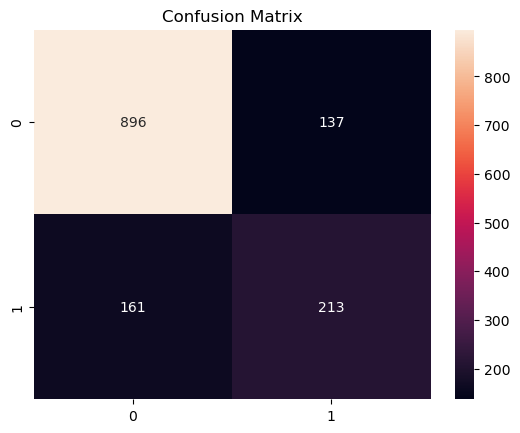

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
 # ROC CURVE

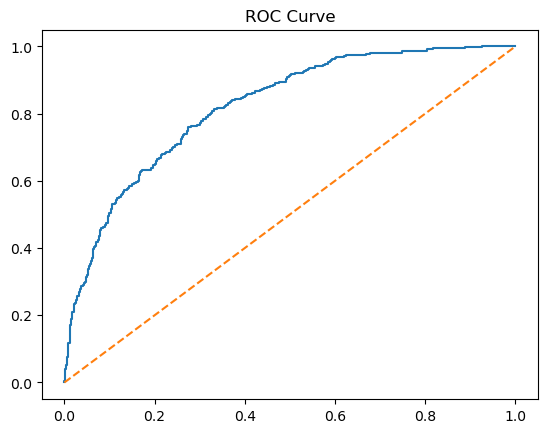

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve")
plt.show()

In [ ]:
# SHAP EXPLAINABILITY 

 99%|===================| 1386/1407 [00:17<00:00]        

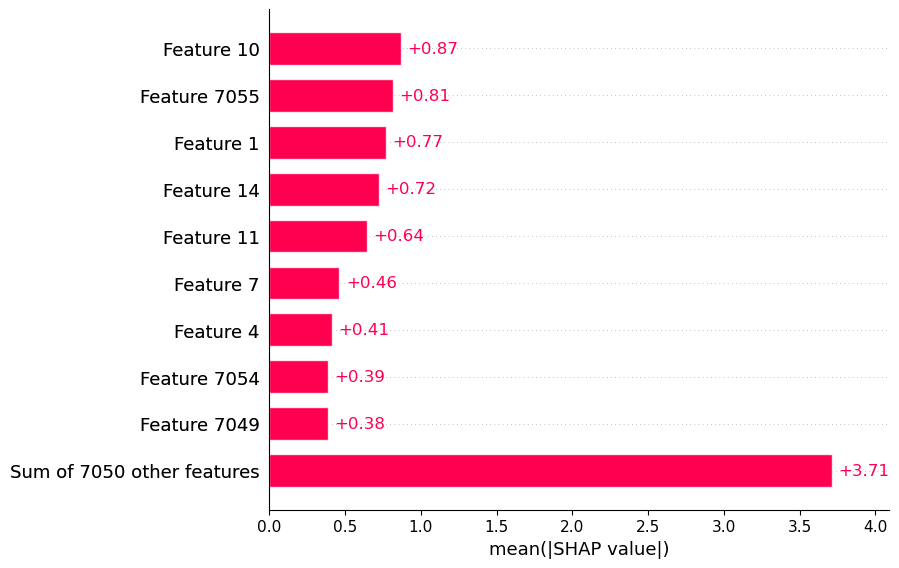

In [32]:
explainer = shap.Explainer(best_xgb, X_train)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [ ]:
# CUSTOMER SEGMENTATION 

In [33]:
kmeans = KMeans(n_clusters=3)
df['Segment'] = kmeans.fit_predict(X)

print("\nCustomer Segments:\n")
print(df.groupby('Segment').mean())


Customer Segments:

         SeniorCitizen     tenure  PhoneService  MultipleLines  \
Segment                                                          
0             0.207325  44.084420      0.860335       0.496586   
1             0.128753  18.249580      0.891424       0.269998   
2             0.216216  64.385533      0.997615       0.829094   

         OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
Segment                                                                
0              0.428926      0.509621          0.521415     0.435754   
1              0.143646      0.158299          0.152774     0.140524   
2              0.577107      0.751192          0.748808     0.598569   

         StreamingTV  StreamingMovies  ...  InternetService_Fiber optic  \
Segment                                ...                                
0           0.544382         0.551210  ...                     0.509001   
1           0.194811         0.195532  ...                    

In [ ]:
# FINAL PREDICTION FUNCTION

In [3]:
def predict_customer(data):
    data_df = pd.DataFrame([data], columns=X.columns)
    data_scaled = scaler.transform(data_df)

    pred = stack.predict(data_scaled)[0]
    prob = stack.predict_proba(data_scaled)[0][1]

    return {
        "Churn Prediction": "Yes" if pred == 1 else "No",
        "Churn Probability": float(round(prob, 3))
    }

In [53]:
sample = X.iloc[0].to_dict()

result = predict_customer(sample)
print(result)

{'Churn Prediction': 'Yes', 'Churn Probability': np.float64(0.692)}


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
try:
    pipeline = {
        "model": stack,
        "scaler": scaler,
        "features": X.columns.tolist()
    }

    with open("churn_pipeline.pkl", "wb") as f:
        pickle.dump(pipeline, f)

    print("✅ Model saved successfully")

except NameError as e:
    print("❌ Error:", e)
    print("👉 Make sure model is trained before saving")

❌ Error: name 'stack' is not defined
👉 Make sure model is trained before saving


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Advanced Customer Churn_Presentation.pptx', 'churn_pipeline.pkl', 'CUSTOMER CHURN ML SYSTEM23.ipynb', 'Data collection.docx', 'Data Preprocessing.docx', 'Deployment.ipynb', 'Feature Selection and Model Creation.docx', 'Final Model Explanation.docx', 'Final Model.docx', 'New folder', 'TelcoCustomerChurn.csv', 'Univariate and Bivariate Analysis.docx', '~$w to share project on below each separate topics.docx']
